# Problem 1

Use of gradient descent, multi-point (multi-start) to find the local minima.
Generate gradient descent with multiple starting points using CUDA, can be based using hill climbing

In [ ]:
import numpy as np
import pycuda.driver as drv
import pycuda.autoinit
from pycuda.compiler import SourceModule
import matplotlib.pyplot as plt

In [ ]:
#kernel definition

mod = SourceModule("""
__global__ void multi_start_gd(float *points, float lr, int iterations, int n)
{
  int idx = threadIdx.x + blockIdx.x * blockDim.x;
  if (idx < n){
    float x = points[idx];

    // gradient descent loop
    for (int i = 0; i < iterations; i++){
      // f(x) = x^2 + 10*sin(x)
      // f'(x) = 2*x + 10*cos(x)
      float gradient = 2.0f*x+10.0f*cosf(x);
      x = x - lr * gradient;
    }
    points[idx] = x; // overwrite local min found
  }
}
    """
)

In [ ]:
N = 1024 #starting points
iterations = 1000
learning_rate = 0.01

start_points = np.random.uniform(-10,10,N).astype(np.float32)
res_points = start_points.copy()

In [ ]:
gd_kernel = mod.get_function("multi_start_gd")
gd_kernel(
    drv.InOut(res_points),
    np.float32(learning_rate),
    np.int32(iterations),
    np.int32(N),
    block = (256,1,1),
    grid=(int(np.ceil(N/256)),1)
)

In [ ]:
print(f"first 5 starting points: {start_points[:5]}")
print(f"first 5 local minima found: {res_points[:5]}")
print(f"global minimum found: {np.min(res_points)}")

first 5 starting points: [ 4.809615   9.882414   9.4745    -0.7182164 -9.849012 ]
first 5 local minima found: [ 3.8374684  3.8374684  3.8374684 -1.3064395 -1.3064405]
global minimum found: -1.3064404726028442


In [ ]:
def f(x):
  return x**2 + 10*np.sin(x)

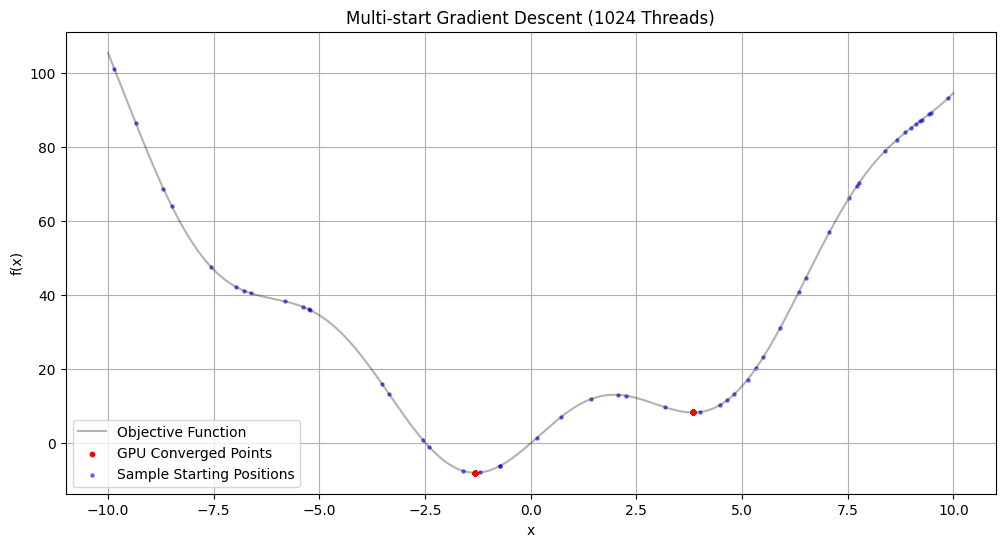

In [ ]:
#plotting

x_range = np.linspace(-10,10,1000)
plt.figure(figsize=(12,6))

plt.plot(x_range, f(x_range), label = 'Objective Function',
         color = 'black',
         alpha = 0.3)

plt.scatter(res_points, f(res_points),
            color='red',
            s=10,
            label='GPU Converged Points',
            zorder=3)

plt.scatter(start_points[:50],f(start_points[:50]),
            color='blue',
            s=5,
            label='Sample Starting Positions',
            alpha=0.5)

plt.title(f"Multi-start Gradient Descent ({N} Threads)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
best_x = res_points[np.argmin(f(res_points))]
print(f"Global Minimum found by GPU: x = {best_x:.4f}, f(x) = {f(best_x):.4f}")

Global Minimum found by GPU: x = -1.3064, f(x) = -7.9458
